In [1]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!pip install -q pyspark==3.5.0 findspark datasets

import os
import findspark
from pyspark.sql import SparkSession
from google.colab import drive

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
findspark.init()

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("MSBDA882_Project_Final") \
    .getOrCreate()

drive.mount('/content/drive')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.9/316.9 MB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 12.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.0 which is incompatible.
Mounted at /content/drive


In [2]:
from datasets import load_dataset
import pandas as pd
import pyspark.sql.functions as F
from pyspark.sql.functions import lit

dataset_name = "KFUPM-JRCAI/arabic-generated-abstracts"
raw_data = load_dataset(dataset_name)

full_pdf = pd.concat([pd.DataFrame(raw_data[split]) for split in raw_data.keys()])
df = spark.createDataFrame(full_pdf)

human_df = df.select(F.col("original_abstract").alias("text")).withColumn("label", lit(0))

ai_df = df.select(F.explode(F.array(
    "allam_generated_abstract",
    "jais_generated_abstract",
    "llama_generated_abstract",
    "openai_generated_abstract"
)).alias("text")).withColumn("label", lit(1))

fraction = human_df.count() / ai_df.count()
balanced_ai_df = ai_df.sample(withReplacement=False, fraction=fraction, seed=42)

dataset_df = human_df.union(balanced_ai_df)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/by_polishing-00000-of-00001.parquet:   0%|          | 0.00/8.49M [00:00<?, ?B/s]

data/from_title-00000-of-00001.parquet:   0%|          | 0.00/6.90M [00:00<?, ?B/s]

data/from_title_and_content-00000-of-000(…):   0%|          | 0.00/7.01M [00:00<?, ?B/s]

Generating by_polishing split:   0%|          | 0/2851 [00:00<?, ? examples/s]

Generating from_title split:   0%|          | 0/2963 [00:00<?, ? examples/s]

Generating from_title_and_content split:   0%|          | 0/2574 [00:00<?, ? examples/s]

In [3]:
def clean_arabic_text(df, column_name):
    df = df.withColumn(column_name, F.regexp_replace(F.col(column_name), r"[\u064B-\u0652]", ""))
    df = df.withColumn(column_name, F.regexp_replace(F.col(column_name), r"[أإآ]", "ا"))
    df = df.withColumn(column_name, F.regexp_replace(F.col(column_name), r"ة", "ه"))
    df = df.withColumn(column_name, F.regexp_replace(F.col(column_name), r"ى", "ي"))
    df = df.withColumn(column_name, F.regexp_replace(F.col(column_name), r"[^أ-ي\s]", ""))
    df = df.withColumn(column_name, F.trim(F.regexp_replace(F.col(column_name), r"\s+", " ")))
    return df

cleaned_df = clean_arabic_text(dataset_df, "text")

In [4]:
file_path = "/content/drive/MyDrive/MSBDA882_Project/processed_features.parquet"
ready_df = spark.read.parquet(file_path)

In [5]:
from pyspark.ml.feature import Tokenizer, HashingTF, IDF, VectorAssembler, StandardScaler

tokenizer = Tokenizer(inputCol="text", outputCol="words")
words_data = tokenizer.transform(ready_df)

hashingTF = HashingTF(inputCol="words", outputCol="raw_tf", numFeatures=2000)
tf_data = hashingTF.transform(words_data)

idf = IDF(inputCol="raw_tf", outputCol="tfidf_features")
idf_model = idf.fit(tf_data)
tfidf_df = idf_model.transform(tf_data)

assembler = VectorAssembler(
    inputCols=["f15_word_var", "f38_char_para", "f61_cmd_count", "f84_sent_len", "f107_formality", "tfidf_features"],
    outputCol="unscaled_features"
)
assembled_df = assembler.transform(tfidf_df)

scaler = StandardScaler(inputCol="unscaled_features", outputCol="features", withStd=True, withMean=False)
scaler_model = scaler.fit(assembled_df)
final_data = scaler_model.transform(assembled_df).select("features", "label")

train_df, val_df, test_df = final_data.randomSplit([0.7, 0.15, 0.15], seed=42)
train_df.cache()

DataFrame[features: vector, label: int]

In [6]:
from pyspark.ml.classification import NaiveBayes, RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy")

nb_model = NaiveBayes().fit(train_df)
nb_preds = nb_model.transform(val_df)
nb_acc = evaluator.evaluate(nb_preds)

rf_model = RandomForestClassifier(numTrees=100, seed=42).fit(train_df)
rf_preds = rf_model.transform(val_df)
rf_acc = evaluator.evaluate(rf_preds)

gbt_model = GBTClassifier(maxIter=20, seed=42).fit(train_df)
gbt_preds = gbt_model.transform(val_df)
gbt_acc = evaluator.evaluate(gbt_preds)

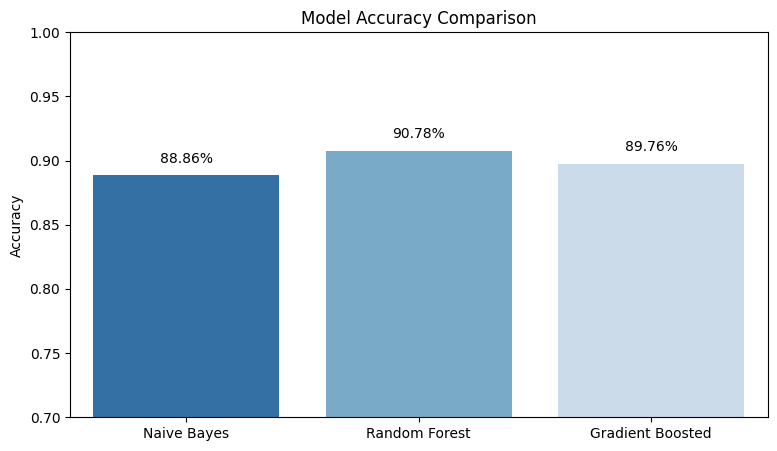

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))
models_names = ['Naive Bayes', 'Random Forest', 'Gradient Boosted']
accuracies = [nb_acc, rf_acc, gbt_acc]

ax = sns.barplot(x=models_names, y=accuracies, hue=models_names, palette='Blues_r', legend=False)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.70, 1.0)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2%}", ha='center')

plt.show()

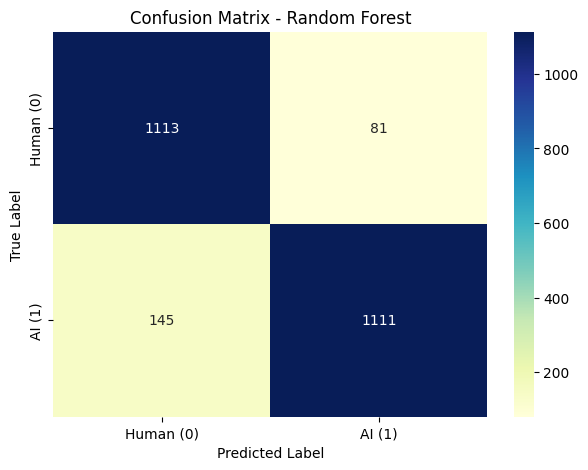

In [8]:
from sklearn.metrics import confusion_matrix
import pandas as pd

y_true = rf_preds.select("label").toPandas()
y_pred = rf_preds.select("prediction").toPandas()

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['Human (0)', 'AI (1)'],
            yticklabels=['Human (0)', 'AI (1)'])

plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

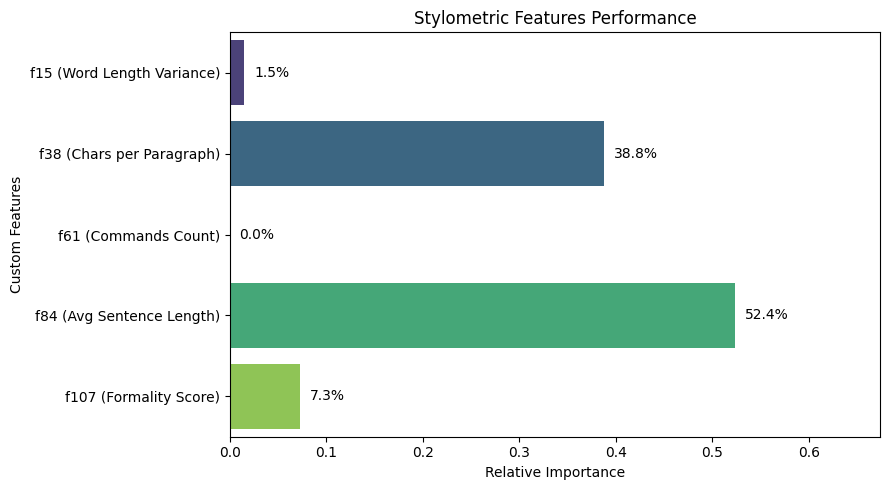

In [9]:
import numpy as np

importances = rf_model.featureImportances.toArray()

f15_imp = importances[0]
f38_imp = importances[1]
f61_imp = importances[2]
f84_imp = importances[3]
f107_imp = importances[4]

total_stylometric = f15_imp + f38_imp + f61_imp + f84_imp + f107_imp
f15_rel = f15_imp / total_stylometric
f38_rel = f38_imp / total_stylometric
f61_rel = f61_imp / total_stylometric
f84_rel = f84_imp / total_stylometric
f107_rel = f107_imp / total_stylometric

features_only = [
    "f15 (Word Length Variance)",
    "f38 (Chars per Paragraph)",
    "f61 (Commands Count)",
    "f84 (Avg Sentence Length)",
    "f107 (Formality Score)"
]
rel_values = [float(f15_rel), float(f38_rel), float(f61_rel), float(f84_rel), float(f107_rel)]

plt.figure(figsize=(9, 5))
ax = sns.barplot(x=rel_values, y=features_only, hue=features_only, palette="viridis", legend=False)

plt.title("Stylometric Features Performance")
plt.xlabel("Relative Importance")
plt.ylabel("Custom Features")

for index, value in enumerate(rel_values):
    plt.text(value + 0.01, index, f"{value:.1%}", va='center')

plt.xlim(0, max(rel_values) + 0.15)
plt.tight_layout()
plt.show()

In [10]:
full_scaled_data = scaler_model.transform(assembled_df)
full_predictions = rf_model.transform(full_scaled_data)

export_spark_df = full_predictions.select(
    "text", "label", "prediction",
    "f15_word_var", "f38_char_para", "f61_cmd_count", "f84_sent_len", "f107_formality"
)

export_pd = export_spark_df.toPandas()

export_pd['True_Source'] = export_pd['label'].apply(lambda x: 'Human' if x == 0 else 'AI')
export_pd['Model_Prediction'] = export_pd['prediction'].apply(lambda x: 'Human' if x == 0 else 'AI')
export_pd['Is_Correct'] = export_pd['label'] == export_pd['prediction']

columns_order = [
    'text', 'True_Source', 'Model_Prediction', 'Is_Correct',
    'f15_word_var', 'f38_char_para', 'f61_cmd_count', 'f84_sent_len', 'f107_formality'
]
export_pd = export_pd[columns_order]

export_pd.to_excel("Full_Dataset_Predictions.xlsx", index=False)

In [11]:
import os

rf_model.save("final_rf_model")
scaler_model.save("final_scaler")

os.makedirs("stream_input", exist_ok=True)

In [12]:
from pyspark.ml.classification import RandomForestClassificationModel
from pyspark.ml.feature import StandardScalerModel
from pyspark.sql.types import StructType, StructField, StringType, IntegerType

loaded_rf = RandomForestClassificationModel.load("final_rf_model")
loaded_scaler = StandardScalerModel.load("final_scaler")

user_schema = StructType([
    StructField("text", StringType(), True),
    StructField("label", IntegerType(), True)
])

streaming_raw_df = spark.readStream \
    .schema(user_schema) \
    .json("stream_input")

query = streaming_raw_df.writeStream \
    .outputMode("append") \
    .format("console") \
    .start()

In [13]:
import time
import json

test_sample_pd = ready_df.select("text", "label").limit(20).toPandas()

for i in range(5):
    sample = test_sample_pd.sample(1).iloc[0]

    message = {
        "text": str(sample['text']),
        "label": int(sample['label'])
    }

    file_name = f"stream_input/msg_{i}_{int(time.time())}.json"
    with open(file_name, 'w', encoding='utf-8') as f:
        json.dump(message, f, ensure_ascii=False)

    time.sleep(5)

In [14]:
check_stream = spark.read.json("stream_input")
check_stream.select("text", "label").show(10, truncate=70)

+----------------------------------------------------------------------+-----+
|                                                                  text|label|
+----------------------------------------------------------------------+-----+
|اكدت هذه الدراسه انه علي الرغم من الجهود الكبيره التي تبذلها الجزائ...|    0|
|تبدو العلاقه بين الفلسفه والعلوم الانسانيه علاقه ذات مسارب مختلفه ا...|    0|
|دفع تفاقم الانكماش الاقتصادي العالمي بالسلطات النقديه لاهم البلدان ...|    0|
|تعد ولايه البويره التي تقع جنوب شرق الجزائر العاصمه من المناطق التي...|    0|
|تتسم الكتابه العلميه بالحكامه والجوده والدقه والمسؤوليه الاخلاقيه و...|    0|
+----------------------------------------------------------------------+-----+



In [15]:
query.stop()